In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributions as distributions
import numpy as np
import gymnasium as gym

# Hyperparameters
ENV_NAME = "CartPole-v1"
GAMMA = 0.99
LEARNING_RATE = 3e-4
CLIP_EPSILON = 0.2         # PPO's characteristic clipping boundary
PPO_EPOCHS = 4              # how many times to reuse each rollout for training
NUM_EPISODES = 300

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


class ActorCritic(nn.Module):
    """
    Shared body, two heads:
    - actor head: outputs action probabilities (the policy)
    - critic head: outputs a single value estimate (how good is this state)
    """
    def __init__(self, obs_dim: int, action_dim: int):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
        )
        self.actor_head = nn.Linear(128, action_dim)   # -> logits over actions
        self.critic_head = nn.Linear(128, 1)             # -> single value estimate

    def forward(self, x):
        features = self.shared(x)
        action_logits = self.actor_head(features)
        value = self.critic_head(features)
        return action_logits, value

Using device: cuda


In [ ]:
env = gym.make(ENV_NAME)
obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

model = ActorCritic(obs_dim, action_dim).to(device)
print(model)

obs, info = env.reset(seed=0)
obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
action_logits, value = model(obs_tensor)

print(f"Action logits: {action_logits}")
print(f"Value estimate: {value}")

dist = distributions.Categorical(logits=action_logits)
action = dist.sample()
log_prob = dist.log_prob(action)

print(f"Sampled action: {action.item()}")
print(f"Log probability of that action: {log_prob.item():.4f}")

env.close()

ActorCritic(
  (shared): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (actor_head): Linear(in_features=128, out_features=2, bias=True)
  (critic_head): Linear(in_features=128, out_features=1, bias=True)
)
Action logits: tensor([[ 0.0372, -0.1127]], device='cuda:0', grad_fn=<AddmmBackward0>)
Value estimate: tensor([[-0.0918]], device='cuda:0', grad_fn=<AddmmBackward0>)
Sampled action: 1
Log probability of that action: -0.7709


In [ ]:
def collect_rollout(env, model, n_steps):
    """
    Run the current policy for n_steps and collect experiences.
    Unlike DQN's replay buffer, this data is fresh (on-policy) and used once.
    """
    obs_list, action_list, reward_list = [], [], []
    log_prob_list, value_list, done_list = [], [], []

    obs, info = env.reset()
    for _ in range(n_steps):
        obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)

        with torch.no_grad():
            action_logits, value = model(obs_tensor)
            dist = distributions.Categorical(logits=action_logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)

        next_obs, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated

        obs_list.append(obs)
        action_list.append(action.item())
        reward_list.append(reward)
        log_prob_list.append(log_prob.item())
        value_list.append(value.item())
        done_list.append(done)

        obs = next_obs
        if done:
            obs, info = env.reset()

    return {
        "obs": np.array(obs_list),
        "actions": np.array(action_list),
        "rewards": np.array(reward_list),
        "log_probs": np.array(log_prob_list),
        "values": np.array(value_list),
        "dones": np.array(done_list),
    }

In [ ]:
N_STEPS = 2048  # how many steps to collect per rollout

env = gym.make(ENV_NAME)
rollout = collect_rollout(env, model, N_STEPS)
env.close()

for key, val in rollout.items():
    print(f"{key}: shape {val.shape}, dtype {val.dtype}")

print(f"\nTotal reward collected: {rollout['rewards'].sum():.0f}")
print(f"Number of episodes finished: {rollout['dones'].sum():.0f}")

obs: shape (2048, 4), dtype float32
actions: shape (2048,), dtype int64
rewards: shape (2048,), dtype float64
log_probs: shape (2048,), dtype float64
values: shape (2048,), dtype float64
dones: shape (2048,), dtype bool

Total reward collected: 2048
Number of episodes finished: 90


In [ ]:
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    """
    Generalized Advantage Estimation.
    Walks backward through the rollout, computing how much better each action
    was compared to what the critic expected.
    """
    advantages = np.zeros_like(rewards)
    last_advantage = 0.0
    last_value = 0.0  # value after the last step (0 because rollout ended)

    # walk backward: future information flows back to earlier steps
    for t in reversed(range(len(rewards))):
        # if this step ended an episode, there is no future to bootstrap from
        mask = 1.0 - dones[t]

        # TD error: reward + discounted next value - current value
        delta = rewards[t] + gamma * last_value * mask - values[t]

        # GAE: accumulate delta with decay (gamma * lam)
        last_advantage = delta + gamma * lam * mask * last_advantage
        advantages[t] = last_advantage

        last_value = values[t]

    # returns = advantages + values (used as the critic's training target)
    returns = advantages + values
    return advantages, returns

In [ ]:
advantages, returns = compute_gae(
    rollout["rewards"],
    rollout["values"],
    rollout["dones"],
    gamma=GAMMA if "GAMMA" in dir() else 0.99,
    lam=0.95
)

print(f"Advantages shape: {advantages.shape}")
print(f"Returns shape: {returns.shape}")
print(f"\nAdvantage stats:")
print(f"  mean: {advantages.mean():.4f}")
print(f"  std:  {advantages.std():.4f}")
print(f"  min:  {advantages.min():.4f}")
print(f"  max:  {advantages.max():.4f}")

Advantages shape: (2048,)
Returns shape: (2048,)

Advantage stats:
  mean: 8.6265
  std:  4.1069
  min:  1.0309
  max:  16.4535


In [ ]:
def ppo_loss(model, obs, actions, old_log_probs, advantages, returns,
             clip_eps=0.2, value_coef=0.5, entropy_coef=0.01):
    """
    PPO's clipped surrogate objective + value loss + entropy bonus.
    """
    obs_t = torch.FloatTensor(obs).to(device)
    actions_t = torch.LongTensor(actions).to(device)
    old_log_probs_t = torch.FloatTensor(old_log_probs).to(device)
    advantages_t = torch.FloatTensor(advantages).to(device)
    returns_t = torch.FloatTensor(returns).to(device)

    # normalize advantages: stabilizes training
    advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)

    # forward pass with the CURRENT policy
    action_logits, values = model(obs_t)
    dist = distributions.Categorical(logits=action_logits)
    new_log_probs = dist.log_prob(actions_t)
    entropy = dist.entropy().mean()

    # ratio = how much the new policy differs from the old one for these actions
    ratio = torch.exp(new_log_probs - old_log_probs_t)

    # clipped surrogate objective
    surr1 = ratio * advantages_t
    surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages_t
    policy_loss = -torch.min(surr1, surr2).mean()

    # critic loss: value estimates should match actual returns
    value_loss = nn.functional.mse_loss(values.squeeze(-1), returns_t)

    # total loss
    loss = policy_loss + value_coef * value_loss - entropy_coef * entropy
    return loss, policy_loss.item(), value_loss.item(), entropy.item()

In [ ]:
loss, p_loss, v_loss, ent = ppo_loss(
    model,
    rollout["obs"],
    rollout["actions"],
    rollout["log_probs"],
    advantages,
    returns
)

print(f"Total loss:  {loss.item():.4f}")
print(f"Policy loss: {p_loss:.4f}")
print(f"Value loss:  {v_loss:.4f}")
print(f"Entropy:     {ent:.4f}")

Total loss:  45.6346
Policy loss: 0.0000
Value loss:  91.2831
Entropy:     0.6900


In [ ]:
def train_ppo(num_iterations=50, n_steps=2048, n_epochs=10, batch_size=64, lr=3e-4):
    env = gym.make(ENV_NAME)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    iteration_rewards = []

    for iteration in range(num_iterations):
        # 1. collect a fresh rollout with the current policy
        rollout = collect_rollout(env, model, n_steps)

        # 2. compute advantages and returns
        advantages, returns = compute_gae(
            rollout["rewards"], rollout["values"], rollout["dones"],
            gamma=0.99, lam=0.95
        )

        # 3. train for several epochs on this rollout (mini-batches)
        n_samples = len(rollout["obs"])
        indices = np.arange(n_samples)

        for epoch in range(n_epochs):
            np.random.shuffle(indices)
            for start in range(0, n_samples, batch_size):
                batch_idx = indices[start:start + batch_size]

                loss, p_loss, v_loss, ent = ppo_loss(
                    model,
                    rollout["obs"][batch_idx],
                    rollout["actions"][batch_idx],
                    rollout["log_probs"][batch_idx],
                    advantages[batch_idx],
                    returns[batch_idx],
                )

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # 4. track performance: average episode length in this rollout
        n_episodes = rollout["dones"].sum()
        avg_ep_reward = rollout["rewards"].sum() / max(n_episodes, 1)
        iteration_rewards.append(avg_ep_reward)

        if (iteration + 1) % 5 == 0:
            print(f"Iter {iteration+1}/{num_iterations} | "
                  f"Avg episode reward: {avg_ep_reward:.1f} | "
                  f"Value loss: {v_loss:.2f} | "
                  f"Entropy: {ent:.3f}")

    env.close()
    return iteration_rewards

In [ ]:
# fresh model so training starts clean
model = ActorCritic(obs_dim, action_dim).to(device)

iteration_rewards = train_ppo(num_iterations=50)

Iter 5/50 | Avg episode reward: 75.9 | Value loss: 33.87 | Entropy: 0.585
Iter 10/50 | Avg episode reward: 170.7 | Value loss: 91.30 | Entropy: 0.587
Iter 15/50 | Avg episode reward: 204.8 | Value loss: 29.86 | Entropy: 0.611
Iter 20/50 | Avg episode reward: 227.6 | Value loss: 27.81 | Entropy: 0.553
Iter 25/50 | Avg episode reward: 227.6 | Value loss: 96.60 | Entropy: 0.576
Iter 30/50 | Avg episode reward: 256.0 | Value loss: 7.20 | Entropy: 0.560
Iter 35/50 | Avg episode reward: 256.0 | Value loss: 58.15 | Entropy: 0.564
Iter 40/50 | Avg episode reward: 512.0 | Value loss: 192.01 | Entropy: 0.551
Iter 45/50 | Avg episode reward: 409.6 | Value loss: 62.97 | Entropy: 0.563
Iter 50/50 | Avg episode reward: 512.0 | Value loss: 14.25 | Entropy: 0.565


In [11]:
class QNetwork(nn.Module):
    """DQN's Q-network. Must match the architecture used during DQN training."""
    def __init__(self, obs_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

In [12]:
dqn_net = QNetwork(obs_dim, action_dim).to(device)
dqn_net.load_state_dict(torch.load("dqn_cartpole.pth", map_location=device))
dqn_net.eval()
print("DQN model loaded successfully.")

DQN model loaded successfully.


In [13]:
import imageio

def record_agent(policy_fn, seed=42):
    """Run one episode with a given policy function, return frames and total reward."""
    env = gym.make(ENV_NAME, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)
    frames, total_reward = [], 0
    done = False
    while not done:
        frames.append(env.render())
        action = policy_fn(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
    env.close()
    return frames, total_reward


def dqn_policy(obs):
    obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = dqn_net(obs_t)
    return q_values.argmax().item()


def ppo_policy(obs):
    obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
    with torch.no_grad():
        action_logits, _ = model(obs_t)
        action = action_logits.argmax(dim=-1)  # greedy for eval
    return action.item()


dqn_frames, dqn_reward = record_agent(dqn_policy)
ppo_frames, ppo_reward = record_agent(ppo_policy)

print(f"DQN survived: {dqn_reward:.0f} steps")
print(f"PPO survived: {ppo_reward:.0f} steps")

DQN survived: 252 steps
PPO survived: 500 steps


In [14]:
import numpy as np

def pad_frames(frames, target_len):
    """Repeat the last frame so both videos have the same length."""
    if len(frames) < target_len:
        last = frames[-1]
        frames = frames + [last] * (target_len - len(frames))
    return frames

# make both the same length (pad the shorter one's ending)
max_len = max(len(dqn_frames), len(ppo_frames))
dqn_padded = pad_frames(dqn_frames, max_len)
ppo_padded = pad_frames(ppo_frames, max_len)

# stack each pair of frames side by side (horizontally)
combined_frames = []
for dqn_f, ppo_f in zip(dqn_padded, ppo_padded):
    combined = np.hstack([dqn_f, ppo_f])  # left: DQN, right: PPO
    combined_frames.append(combined)

imageio.mimsave("dqn_vs_ppo.gif", combined_frames, fps=30)
print(f"Saved {len(combined_frames)} frames")
print("Left: DQN | Right: PPO")

Saved 500 frames
Left: DQN | Right: PPO


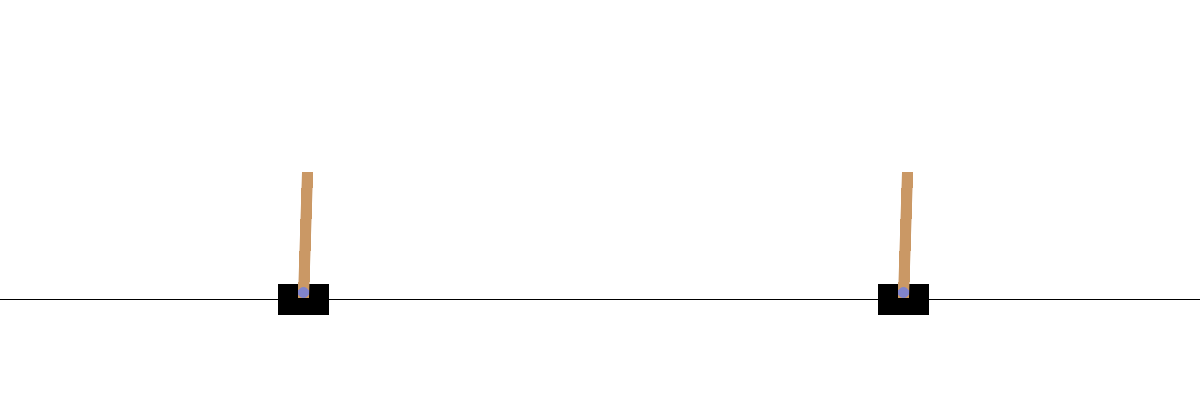

In [16]:
from IPython.display import Image
Image(open("dqn_vs_ppo.gif", "rb").read())

In [17]:
import os
size_mb = os.path.getsize("dqn_vs_ppo.gif") / (1024 * 1024)
print(f"GIF size: {size_mb:.2f} MB")

GIF size: 0.55 MB


In [18]:
torch.save(model.state_dict(), "ppo_cartpole.pth")
print("PPO model saved.")

PPO model saved.
